# Customer Churn Analysis for Telecom Industry

## Predicting Customer Churn and Identifying Retention Strategies Using Machine Learning

Prepared as part of a Data Analytics Internship Project

Tools Used:

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Scikit-learn


## Objective

The objective of this project is to analyze customer behavior and predict customer churn in the telecom industry using machine learning techniques.

The project aims to:

* Identify factors that influence customer churn.
* Analyze customer demographics and service usage patterns.
* Build a predictive model to classify customers as likely to churn or remain.
* Segment customers into different risk categories.
* Provide business recommendations to improve customer retention and reduce churn.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Dataset Overview

In [ ]:
df.shape

(7043, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


##  Missing Values Check

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


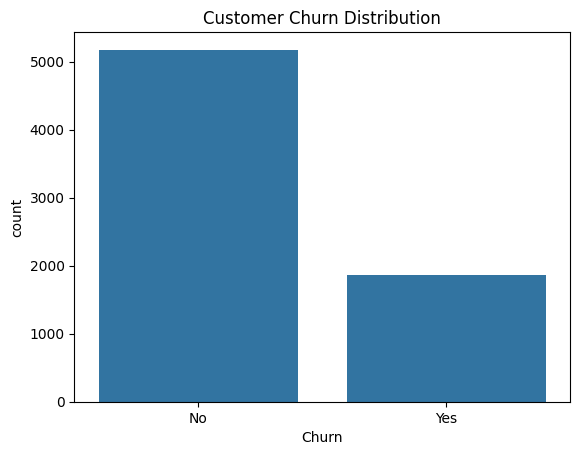

In [ ]:
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

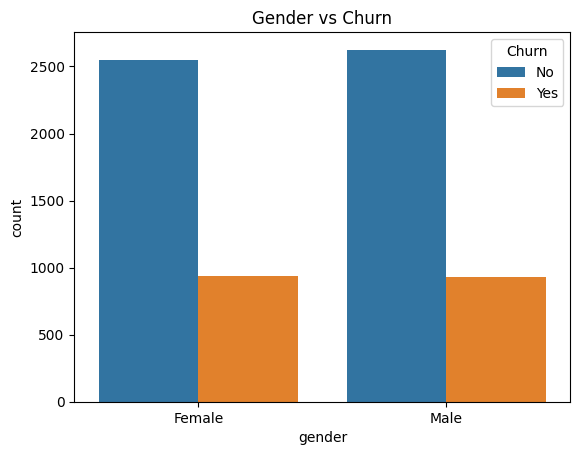

In [ ]:
sns.countplot(x="gender", hue="Churn", data=df)
plt.title("Gender vs Churn")
plt.show()

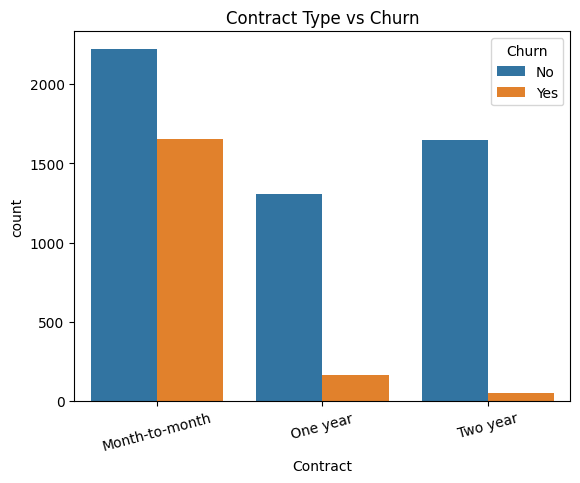

In [ ]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.xticks(rotation=15)
plt.title("Contract Type vs Churn")
plt.show()

## Contract Analysis Findings

1. Most customers remain with the telecom company, while a smaller portion of customers have churned.

2. Customers with month-to-month contracts show the highest churn rate.

3. Customers with one-year and two-year contracts are significantly more likely to stay with the company.

4. Long-term contracts appear to be an effective customer retention strategy.


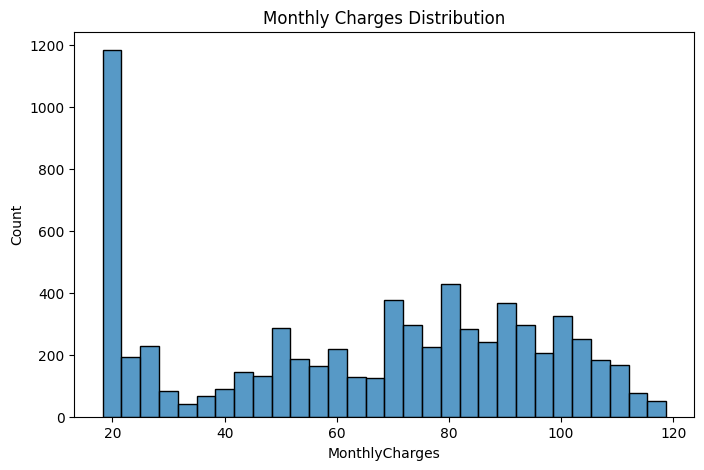

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["MonthlyCharges"], bins=30)
plt.title("Monthly Charges Distribution")
plt.show()

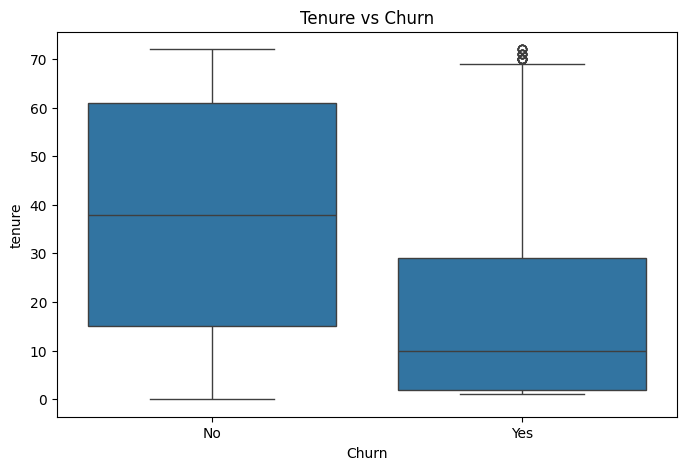

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

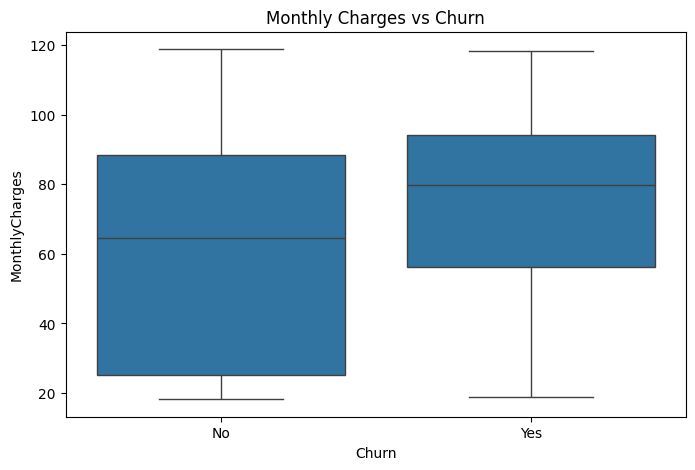

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

## Key Findings from Exploratory Data Analysis

1. Most customers remain with the telecom company, while a smaller percentage have churned.

2. Customers on month-to-month contracts exhibit the highest churn rate, whereas customers on long-term contracts are more likely to stay.

3. Customers with shorter tenure are significantly more likely to churn, indicating that new customers are at greater risk of leaving.

4. Customers with higher monthly charges tend to churn more frequently, suggesting that pricing may influence customer retention.

5. Contract type, tenure, and monthly charges appear to be strong predictors of customer churn.


## Data Preprocessing

Before building the machine learning model, the dataset must be prepared by handling data types, converting categorical variables into numerical form, and separating features from the target variable.


In [ ]:
df["TotalCharges"].dtype

dtype('O')

In [ ]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

## Data Cleaning

The TotalCharges column was stored as a text data type and contained a small number of blank values. These records were removed, and the column was converted to a numeric format to ensure accurate analysis and model training.


In [ ]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

In [ ]:
df = df.dropna()

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [ ]:
df["Churn"].head()

,Churn
0,No
1,No
2,Yes
3,No
4,Yes


In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [ ]:
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,True


In [ ]:
print(df_encoded.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'customerID_0003-MKNFE', 'customerID_0004-TLHLJ', 'customerID_0011-IGKFF', 'customerID_0013-EXCHZ', 'customerID_0013-MHZWF', 'customerID_0013-SMEOE', 'customerID_0014-BMAQU', 'customerID_0015-UOCOJ', 'customerID_0016-QLJIS', 'customerID_0017-DINOC', 'customerID_0017-IUDMW', 'customerID_0018-NYROU', 'customerID_0019-EFAEP', 'customerID_0019-GFNTW', 'customerID_0020-INWCK', 'customerID_0020-JDNXP', 'customerID_0021-IKXGC', 'customerID_0022-TCJCI', 'customerID_0023-HGHWL', 'customerID_0023-UYUPN', 'customerID_0023-XUOPT', 'customerID_0027-KWYKW', 'customerID_0030-FNXPP', 'customerID_0031-PVLZI', 'customerID_0032-PGELS', 'customerID_0036-IHMOT', 'customerID_0040-HALCW', 'customerID_0042-JVWOJ', 'customerID_0042-RLHYP', 'customerID_0048-LUMLS', 'customerID_0048-PIHNL', 'customerID_0052-DCKON', 'customerID_0052-YNYOT', 'customerID_0056-EPFBG', 'customerID_0057-QBUQH', 'customerID_0058-EVZWM', 'customerID_0060-FUALY', 'customerID_0

In [ ]:
print([col for col in df_encoded.columns if "Churn" in col])

['Churn_Yes']


In [ ]:
X = df_encoded.drop("Churn_Yes", axis=1)

y = df_encoded["Churn_Yes"]

In [ ]:
print(X.shape)
print(y.shape)

(7032, 7061)
(7032,)


## Feature Selection

The dataset was transformed into a machine-learning-ready format using one-hot encoding. The target variable was defined as customer churn, while all remaining variables were used as predictive features.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(5625, 7061)
(1407, 7061)


## Train-Test Split

The dataset was divided into training and testing sets. The training data was used to build the machine learning model, while the testing data was used to evaluate its performance on unseen customer records.
"

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7896233120113717


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.82      0.92      0.86      1033
        True       0.66      0.44      0.53       374

    accuracy                           0.79      1407
   macro avg       0.74      0.68      0.70      1407
weighted avg       0.78      0.79      0.77      1407



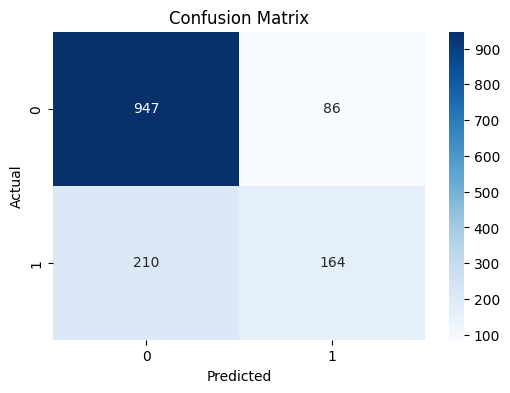

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Model Evaluation

A Random Forest Classifier was trained to predict customer churn. The model was evaluated using accuracy, classification metrics, and a confusion matrix. These evaluation techniques help measure the model's ability to correctly identify customers who are likely to churn.


## Model Performance Summary

The Random Forest model achieved an accuracy of approximately 79% in predicting customer churn.

Key observations:

* The model successfully identified the majority of loyal customers.
* A significant number of churning customers were also detected.
* Contract type, tenure, and monthly charges were found to be important factors influencing churn.
* The model can support telecom companies in identifying customers who may leave and applying targeted retention strategies.


In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,TotalCharges,0.102437
1,tenure,0.095978
2,MonthlyCharges,0.083280
7041,InternetService_Fiber optic,0.026298
7050,TechSupport_Yes,0.021811
7056,Contract_Two year,0.021601
7059,PaymentMethod_Electronic check,0.021445
7044,OnlineSecurity_Yes,0.021355
7055,Contract_One year,0.017938
7057,PaperlessBilling_Yes,0.017083


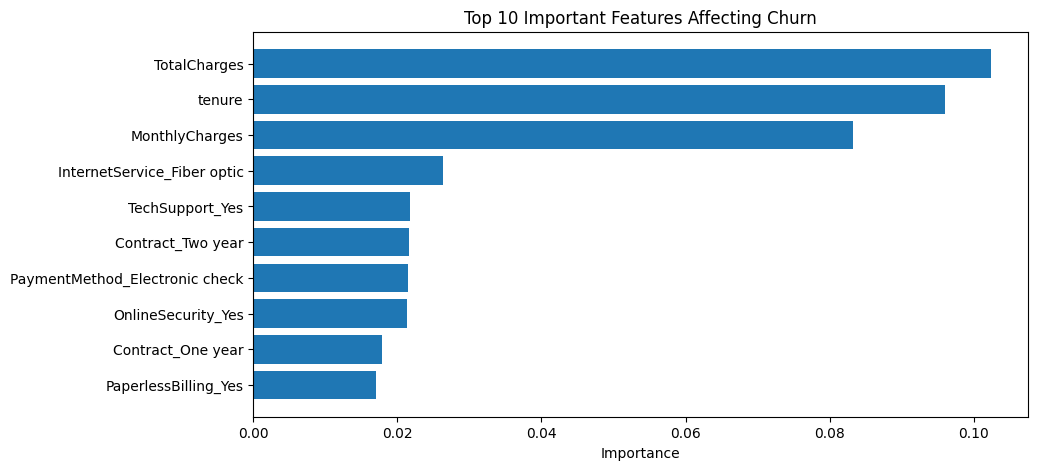

In [ ]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(10,5))
plt.barh(top10["Feature"], top10["Importance"])
plt.title("Top 10 Important Features Affecting Churn")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

## Customer Segmentation

In [ ]:
df["Customer_Segment"] = "Loyal"

df.loc[(df["tenure"] < 12) & (df["Churn"] == 1), "Customer_Segment"] = "At Risk"

df.loc[(df["tenure"] < 6) & (df["MonthlyCharges"] > 70), "Customer_Segment"] = "Dormant"

df["Customer_Segment"].value_counts()

,count
Customer_Segment,
Loyal,6513
Dormant,519


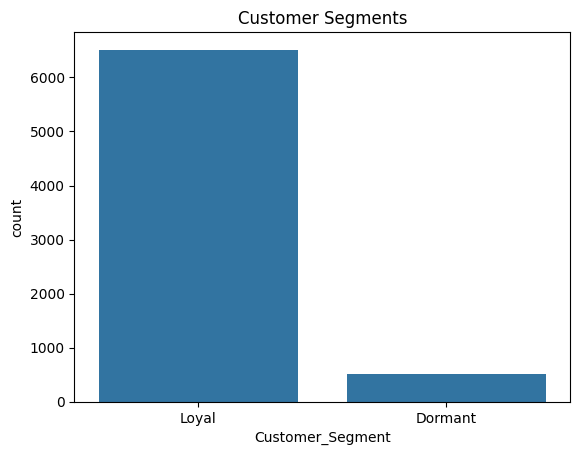

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x="Customer_Segment",
    data=df
)

plt.title("Customer Segments")
plt.show()

In [2]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

NameError: name 'pd' is not defined

## Final Recommendations

1. Encourage customers to move from month-to-month contracts to longer-term contracts through discounts and loyalty rewards.

2. Monitor customers with high monthly charges and provide personalized offers to reduce churn risk.

3. Implement targeted retention campaigns for customers with low tenure, as they are more likely to leave.

4. Improve customer engagement through reward programs, bundled services, and proactive customer support.

5. Use predictive analytics regularly to identify at-risk customers before they churn.


## Conclusion

This project successfully analyzed customer churn patterns in the telecom industry using exploratory data analysis and machine learning techniques. A Random Forest Classifier achieved approximately 79% prediction accuracy. The analysis revealed that contract type, tenure, and monthly charges significantly influence churn behavior. Customer segmentation and predictive modeling can help telecom companies implement effective retention strategies and improve customer loyalty.
